# 05 - Modeling: Customer Segmentation via Clustering

This notebook experiments with three clustering approaches on the preprocessed feature matrix:

1. **KMeans on PCA-reduced features**
2. **KMeans on the full feature set (no PCA)**
3. **DBSCAN on the full feature set (no PCA)**

Each approach is evaluated with the Elbow Method (inertia), Silhouette Score, and the Davies-Bouldin Index. The notebook closes with a comparison across the three approaches, a profile of the winning segmentation, and a final summary.

In [25]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

In [26]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

from src.utils import evaluate_kmeans, plot_kmeans_metrics

RANDOM_STATE = 42

In [27]:
df_processed = pd.read_csv("../data/processed/04_processed.csv")
df_raw_for_profiling = pd.read_csv("../data/processed/03_features.csv")

X = df_processed.values
print("Feature matrix shape (samples, features):", X.shape)

Feature matrix shape (samples, features): (2198, 25)


## Experiment A - KMeans on PCA-Reduced Features

### Choosing the Number of Components

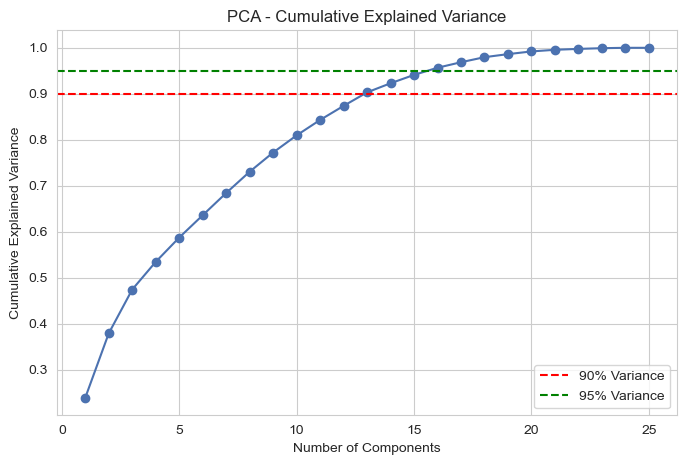

Components needed to keep 90% of variance: 13
Components needed to keep 95% of variance: 16


In [28]:
pca_full = PCA(random_state=RANDOM_STATE).fit(X)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o", color="#4C72B0")
plt.axhline(0.90, color="red", linestyle="--", label="90% Variance")
plt.axhline(0.95, color="green", linestyle="--", label="95% Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

n_components_90 = int(np.argmax(cum_var >= 0.90) + 1)
n_components_95 = int(np.argmax(cum_var >= 0.95) + 1)
print(f"Components needed to keep 90% of variance: {n_components_90}")
print(f"Components needed to keep 95% of variance: {n_components_95}")

In [29]:
n_components = n_components_90

pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

print("Shape after PCA:", X_pca.shape)
print(f"Total variance retained: {pca.explained_variance_ratio_.sum():.4f}")

Shape after PCA: (2198, 13)
Total variance retained: 0.9032


### Elbow, Silhouette, and Davies-Bouldin across k

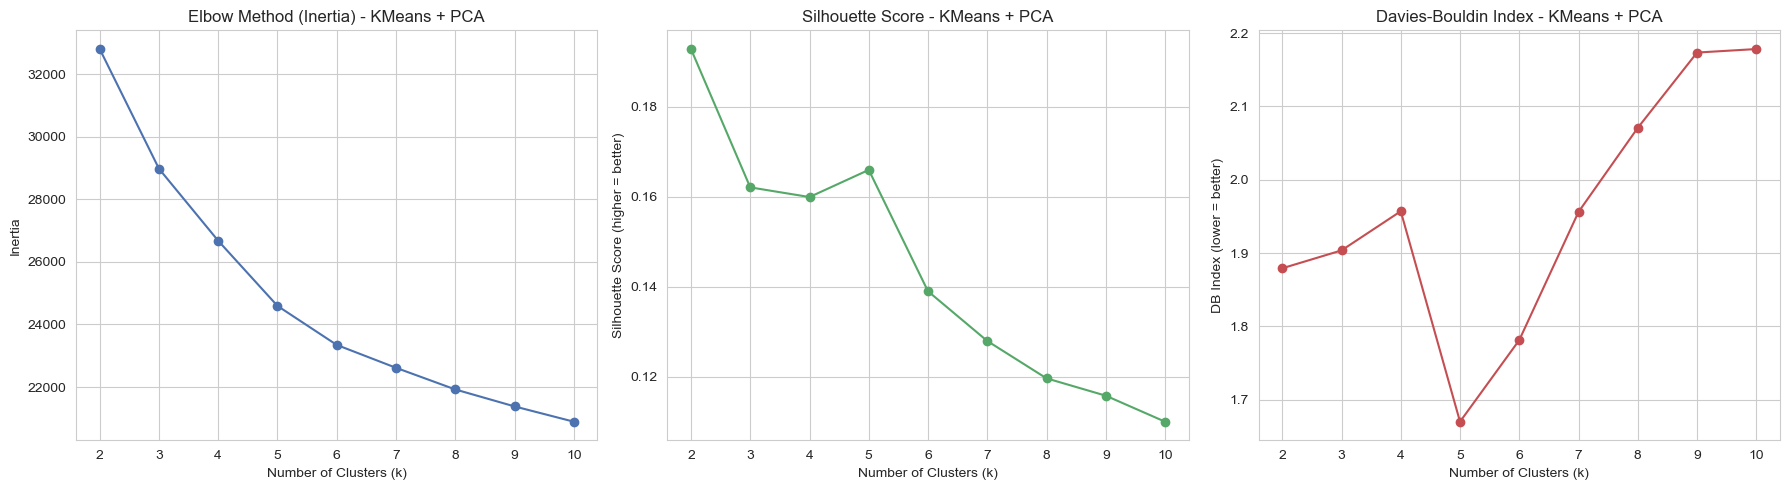

,k,inertia,silhouette,davies_bouldin
0,2,32804.893905,0.192884,1.879194
1,3,28978.872939,0.162119,1.903587
2,4,26674.704547,0.159968,1.956967
3,5,24594.029726,0.166005,1.669972
4,6,23346.705053,0.139010,1.781278
5,7,22615.384393,0.127959,1.956065
6,8,21923.658518,0.119646,2.070766
7,9,21381.459921,0.115789,2.173427
8,10,20893.257888,0.110007,2.178225


In [30]:
k_range = range(2, 11)
kmeans_pca_metrics = evaluate_kmeans(X_pca, k_range, random_state=RANDOM_STATE)
plot_kmeans_metrics(kmeans_pca_metrics, "KMeans + PCA")
kmeans_pca_metrics

The best `k` is chosen based on the highest Silhouette Score, cross-checked against the Elbow curve and the Davies-Bouldin Index rather than relying on a single metric alone.

In [31]:
best_k_pca = int(kmeans_pca_metrics.loc[kmeans_pca_metrics["silhouette"].idxmax(), "k"])
print(f"Best k for 'KMeans + PCA' based on Silhouette Score: {best_k_pca}")

kmeans_pca_final = KMeans(n_clusters=best_k_pca, random_state=RANDOM_STATE, n_init=10)
clusters_pca = kmeans_pca_final.fit_predict(X_pca)

df_processed["Cluster_KMeans_PCA"] = clusters_pca

print()
print(pd.Series(clusters_pca).value_counts().sort_index())

Best k for 'KMeans + PCA' based on Silhouette Score: 2

0    1038
1    1160
Name: count, dtype: int64


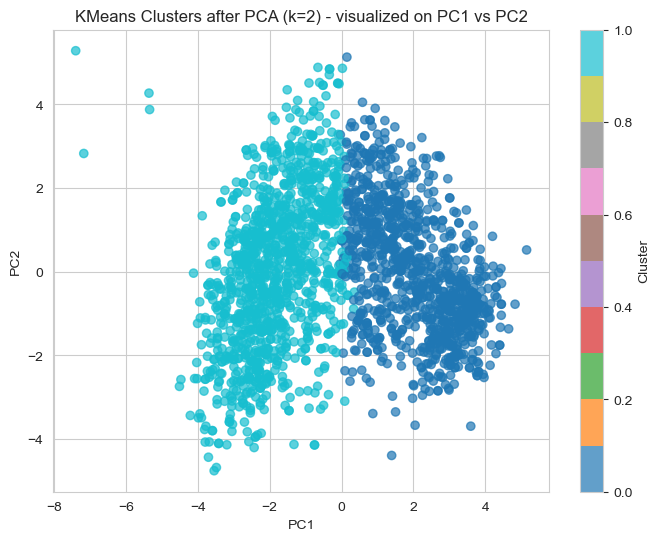

In [32]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_pca, cmap="tab10", alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"KMeans Clusters after PCA (k={best_k_pca}) - visualized on PC1 vs PC2")
plt.colorbar(scatter, label="Cluster")
plt.show()

## Experiment B - KMeans on the Full Feature Set (No PCA)

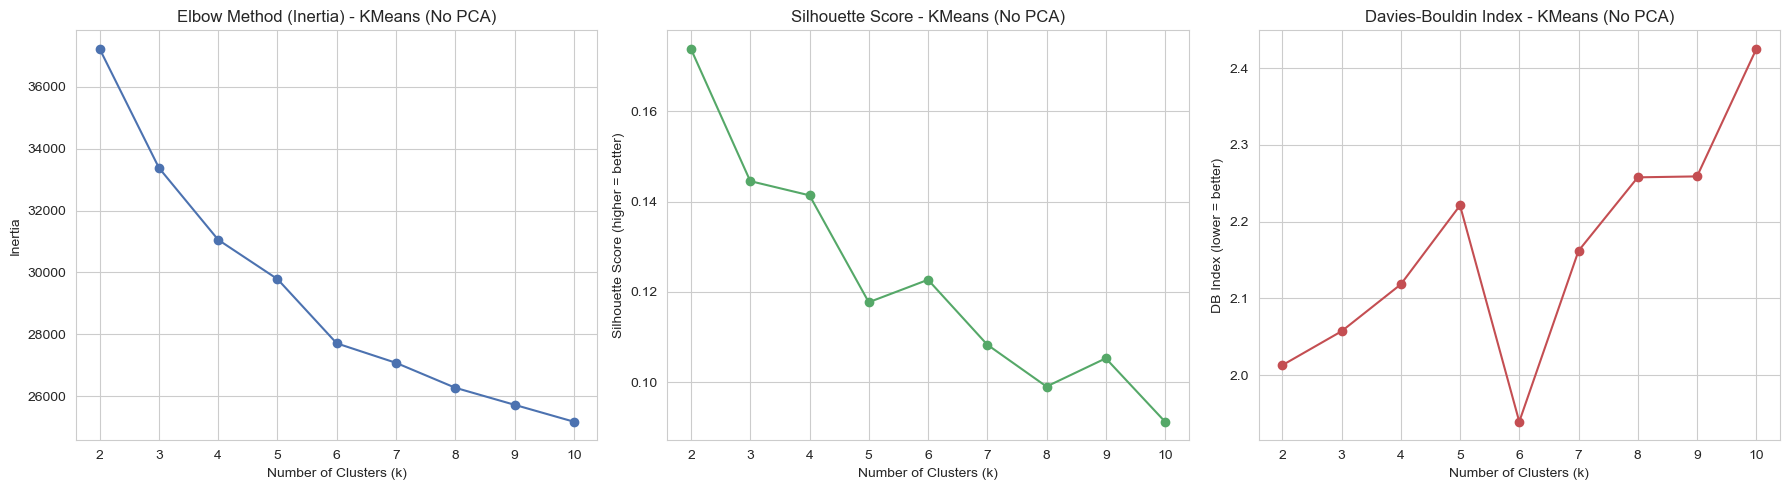

,k,inertia,silhouette,davies_bouldin
0,2,37210.757914,0.173761,2.012738
1,3,33373.584709,0.144519,2.056965
2,4,31053.640747,0.141368,2.118054
3,5,29786.035382,0.117699,2.220944
4,6,27712.655200,0.122676,1.939187
5,7,27083.288886,0.108305,2.161814
6,8,26279.984925,0.099031,2.257539
7,9,25730.176557,0.105283,2.258772
8,10,25184.817880,0.091251,2.424703


In [33]:
kmeans_raw_metrics = evaluate_kmeans(X, k_range, random_state=RANDOM_STATE)
plot_kmeans_metrics(kmeans_raw_metrics, "KMeans (No PCA)")
kmeans_raw_metrics

In [34]:
best_k_raw = int(kmeans_raw_metrics.loc[kmeans_raw_metrics["silhouette"].idxmax(), "k"])
print(f"Best k for 'KMeans (No PCA)' based on Silhouette Score: {best_k_raw}")

kmeans_raw_final = KMeans(n_clusters=best_k_raw, random_state=RANDOM_STATE, n_init=10)
clusters_raw = kmeans_raw_final.fit_predict(X)

df_processed["Cluster_KMeans_Raw"] = clusters_raw

print()
print(pd.Series(clusters_raw).value_counts().sort_index())

Best k for 'KMeans (No PCA)' based on Silhouette Score: 2

0    1028
1    1170
Name: count, dtype: int64


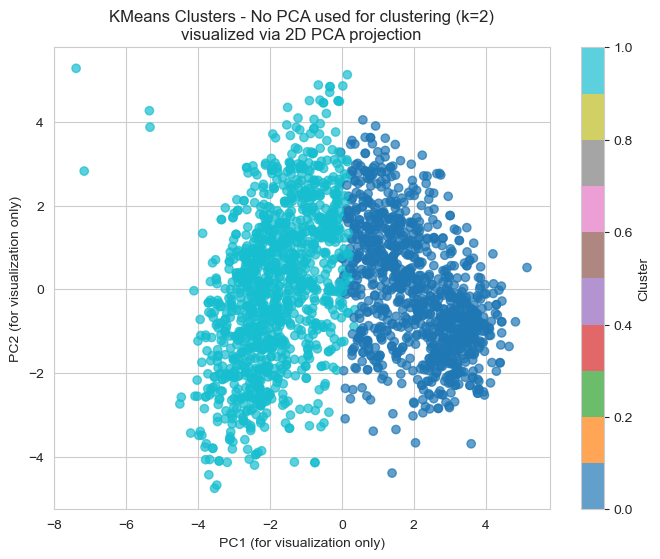

In [35]:
pca_viz = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_viz[:, 0], pca_viz[:, 1], c=clusters_raw, cmap="tab10", alpha=0.7)
plt.xlabel("PC1 (for visualization only)")
plt.ylabel("PC2 (for visualization only)")
plt.title(f"KMeans Clusters - No PCA used for clustering (k={best_k_raw})\nvisualized via 2D PCA projection")
plt.colorbar(scatter, label="Cluster")
plt.show()

## Experiment C - DBSCAN on the Full Feature Set (No PCA)

DBSCAN requires `eps` and `min_samples`. A K-Distance Graph is used to guide the choice of `eps`, followed by a small grid search over `eps` and `min_samples`, selecting the combination with the best Silhouette Score among the noise points.

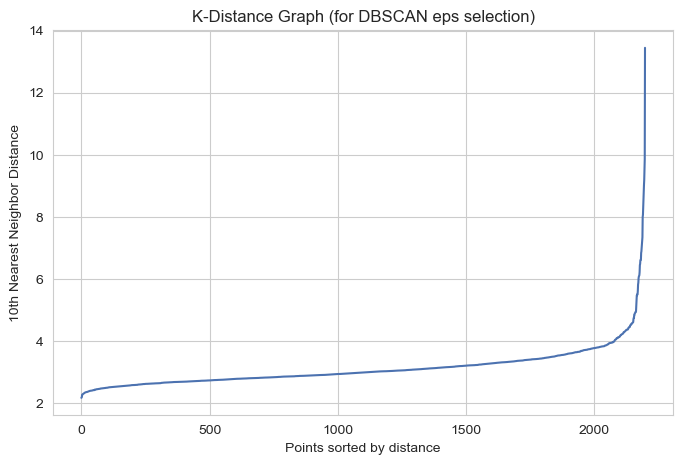

Suggested eps range to try based on the distance distribution: 3.41 - 4.75


In [36]:
k_neighbors = 10
neighbors = NearestNeighbors(n_neighbors=k_neighbors)
neighbors_fit = neighbors.fit(X)
distances, _ = neighbors_fit.kneighbors(X)
distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(distances, color="#4C72B0")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{k_neighbors}th Nearest Neighbor Distance")
plt.title("K-Distance Graph (for DBSCAN eps selection)")
plt.grid(True)
plt.show()

print(f"Suggested eps range to try based on the distance distribution: "
      f"{np.percentile(distances, 80):.2f} - {np.percentile(distances, 98):.2f}")

In [37]:
eps_values = np.round(np.arange(
    np.percentile(distances, 70), np.percentile(distances, 99), 0.25
), 2)
min_samples_values = [5, 10, 15, 20]

dbscan_rows = []
for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = int((labels == -1).sum())
        noise_ratio = n_noise / len(labels)

        sil, db_score = np.nan, np.nan
        if n_clusters >= 2:
            mask = labels != -1
            if mask.sum() > 1 and len(set(labels[mask])) >= 2:
                sil = silhouette_score(X[mask], labels[mask])
                db_score = davies_bouldin_score(X[mask], labels[mask])

        dbscan_rows.append({
            "eps": eps, "min_samples": ms, "n_clusters": n_clusters,
            "noise_ratio": noise_ratio, "silhouette": sil, "davies_bouldin": db_score,
        })

dbscan_results_df = pd.DataFrame(dbscan_rows)
dbscan_results_df.sort_values("silhouette", ascending=False).head(15)

,eps,min_samples,n_clusters,noise_ratio,silhouette,davies_bouldin
44,5.98,5,2,0.005914,0.509308,0.815691
45,5.98,10,2,0.006824,0.508668,0.796240
40,5.73,5,2,0.006369,0.507209,0.802995
41,5.73,10,2,0.007279,0.506255,0.780724
46,5.98,15,2,0.008189,0.506108,0.779483
36,5.48,5,2,0.007279,0.505305,0.787742
12,3.98,5,2,0.015469,0.504835,0.646824
16,4.23,5,2,0.012739,0.504459,0.672061
33,5.23,10,2,0.010464,0.504333,0.699919
20,4.48,5,2,0.011829,0.504320,0.672171


In [38]:
valid_dbscan = dbscan_results_df[
    (dbscan_results_df["n_clusters"].between(2, 10)) &
    (dbscan_results_df["noise_ratio"] < 0.25) &
    (dbscan_results_df["silhouette"].notna())
].sort_values("silhouette", ascending=False)

print(f"Valid parameter combinations found: {len(valid_dbscan)}")
valid_dbscan.head(10)

Valid parameter combinations found: 16


,eps,min_samples,n_clusters,noise_ratio,silhouette,davies_bouldin
44,5.98,5,2,0.005914,0.509308,0.815691
45,5.98,10,2,0.006824,0.508668,0.796240
40,5.73,5,2,0.006369,0.507209,0.802995
41,5.73,10,2,0.007279,0.506255,0.780724
46,5.98,15,2,0.008189,0.506108,0.779483
36,5.48,5,2,0.007279,0.505305,0.787742
12,3.98,5,2,0.015469,0.504835,0.646824
16,4.23,5,2,0.012739,0.504459,0.672061
33,5.23,10,2,0.010464,0.504333,0.699919
20,4.48,5,2,0.011829,0.504320,0.672171


In [39]:
if len(valid_dbscan) > 0:
    best_eps = float(valid_dbscan.iloc[0]["eps"])
    best_min_samples = int(valid_dbscan.iloc[0]["min_samples"])
else:
    fallback = dbscan_results_df.sort_values("silhouette", ascending=False).iloc[0]
    best_eps = float(fallback["eps"])
    best_min_samples = int(fallback["min_samples"])
    print("No combination satisfied all constraints, falling back to the best available result.")

print(f"Chosen DBSCAN params -> eps={best_eps}, min_samples={best_min_samples}")

dbscan_final = DBSCAN(eps=best_eps, min_samples=best_min_samples)
clusters_dbscan = dbscan_final.fit_predict(X)

df_processed["Cluster_DBSCAN"] = clusters_dbscan

n_clusters_db = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
n_noise = int((clusters_dbscan == -1).sum())
print()
print(f"Number of clusters found: {n_clusters_db}")
print(f"Number of noise points: {n_noise} ({n_noise/len(clusters_dbscan):.1%})")
print()
print(pd.Series(clusters_dbscan).value_counts().sort_index())

Chosen DBSCAN params -> eps=5.98, min_samples=5

Number of clusters found: 2
Number of noise points: 13 (0.6%)

-1      13
 0    2165
 1      20
Name: count, dtype: int64


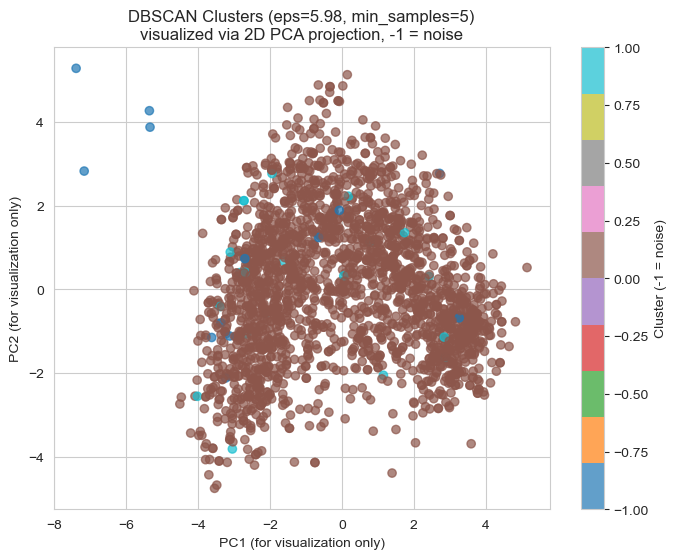

In [40]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_viz[:, 0], pca_viz[:, 1], c=clusters_dbscan, cmap="tab10", alpha=0.7)
plt.xlabel("PC1 (for visualization only)")
plt.ylabel("PC2 (for visualization only)")
plt.title(f"DBSCAN Clusters (eps={best_eps}, min_samples={best_min_samples})\nvisualized via 2D PCA projection, -1 = noise")
plt.colorbar(scatter, label="Cluster (-1 = noise)")
plt.show()

## Model Comparison

In [41]:
mask_db = clusters_dbscan != -1
db_silhouette = silhouette_score(X[mask_db], clusters_dbscan[mask_db]) if n_clusters_db >= 2 else np.nan
db_davies_bouldin = davies_bouldin_score(X[mask_db], clusters_dbscan[mask_db]) if n_clusters_db >= 2 else np.nan

comparison = pd.DataFrame({
    "Model": ["KMeans + PCA", "KMeans (No PCA)", "DBSCAN (No PCA)"],
    "Number of Clusters": [best_k_pca, best_k_raw, n_clusters_db],
    "Silhouette Score": [
        silhouette_score(X_pca, clusters_pca),
        silhouette_score(X, clusters_raw),
        db_silhouette,
    ],
    "Davies-Bouldin Index": [
        davies_bouldin_score(X_pca, clusters_pca),
        davies_bouldin_score(X, clusters_raw),
        db_davies_bouldin,
    ],
    "Noise Points (%)": [0.0, 0.0, round(n_noise / len(clusters_dbscan) * 100, 2)],
})

comparison

,Model,Number of Clusters,Silhouette Score,Davies-Bouldin Index,Noise Points (%)
0,KMeans + PCA,2,0.192884,1.879194,0.00
1,KMeans (No PCA),2,0.173761,2.012738,0.00
2,DBSCAN (No PCA),2,0.509308,0.815691,0.59


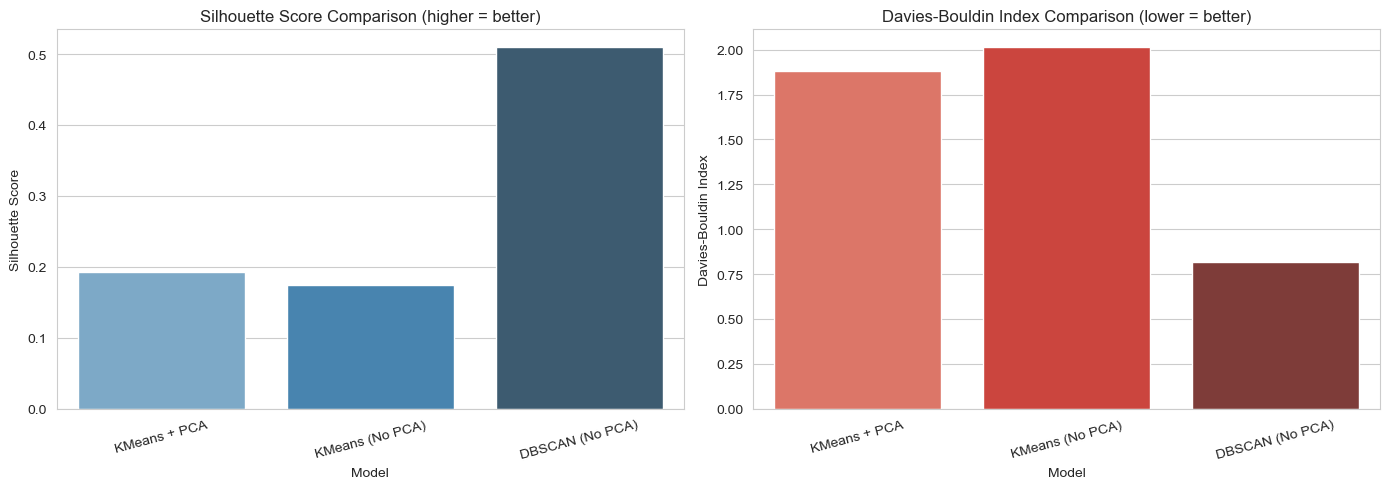

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=comparison, x="Model", y="Silhouette Score", hue="Model", palette="Blues_d", legend=False, ax=axes[0])
axes[0].set_title("Silhouette Score Comparison (higher = better)")
axes[0].tick_params(axis="x", rotation=15)

sns.barplot(data=comparison, x="Model", y="Davies-Bouldin Index", hue="Model", palette="Reds_d", legend=False, ax=axes[1])
axes[1].set_title("Davies-Bouldin Index Comparison (lower = better)")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

In [43]:
best_model_row = comparison.loc[comparison["Silhouette Score"].idxmax()]
best_model_name = best_model_row["Model"]
print(f"Best performing model based on Silhouette Score: {best_model_name}")
print(f"Suggested number of clusters: {int(best_model_row['Number of Clusters'])}")

cluster_col_map = {
    "KMeans + PCA": "Cluster_KMeans_PCA",
    "KMeans (No PCA)": "Cluster_KMeans_Raw",
    "DBSCAN (No PCA)": "Cluster_DBSCAN",
}
best_cluster_col = cluster_col_map[best_model_name]

Best performing model based on Silhouette Score: DBSCAN (No PCA)
Suggested number of clusters: 2


## Cluster Profiling

The winning segmentation is profiled using the original (pre-scaling) feature values, so the clusters can be interpreted in business terms rather than standardized units.

In [44]:
df_profile = df_raw_for_profiling.copy()
df_profile["Cluster"] = df_processed[best_cluster_col].values

profile_cols = [
    "Income", "age", "total_spending", "total_purchases", "total_children",
    "Recency", "Customer_Days", "deals_share", "web_share", "catalog_share", "store_share",
]
profile_cols = [c for c in profile_cols if c in df_profile.columns]

cluster_profile = df_profile.groupby("Cluster")[profile_cols].mean().round(2)
cluster_profile["Count"] = df_profile["Cluster"].value_counts().sort_index()
cluster_profile

,Income,age,total_spending,total_purchases,total_children,Recency,Customer_Days,deals_share,web_share,catalog_share,store_share,Count
Cluster,,,,,,,,,,,,
-1,13403.46,46.77,275.31,13.23,0.85,41.00,261.31,0.29,0.38,0.06,0.12,13
0,51901.18,46.10,610.91,14.90,0.95,49.11,353.55,0.18,0.27,0.14,0.41,2165
1,45672.40,46.65,392.00,13.60,1.20,50.75,429.70,0.22,0.26,0.10,0.42,20


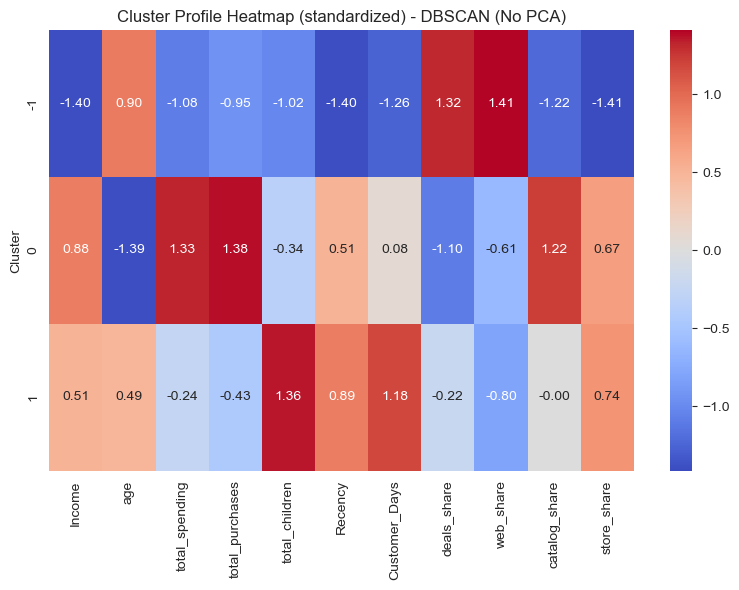

In [45]:
profile_scaled = pd.DataFrame(
    StandardScaler().fit_transform(cluster_profile[profile_cols]),
    columns=profile_cols,
    index=cluster_profile.index,
)

plt.figure(figsize=(8, 6))
sns.heatmap(profile_scaled, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title(f"Cluster Profile Heatmap (standardized) - {best_model_name}")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

## Final Report

### Methodology Summary
- The clustering feature matrix is the output of the preprocessing pipeline (notebook 04): 25 scaled / encoded columns.
- Three experiments were run:
  1. **KMeans + PCA**: dimensionality reduced to retain 90% of variance, then KMeans applied on the reduced space.
  2. **KMeans (No PCA)**: KMeans applied directly on all 25 features.
  3. **DBSCAN (No PCA)**: DBSCAN applied on the same 25 features, with `eps` chosen via a K-Distance Graph and a small grid search over `eps` / `min_samples`.
- Each experiment was evaluated with the Elbow Method (KMeans only), Silhouette Score, and the Davies-Bouldin Index.

### Comparison Results
The `comparison` table above reports the number of clusters, Silhouette Score, Davies-Bouldin Index, and noise ratio for each approach. The model with the highest Silhouette Score (and, for DBSCAN, an acceptable noise ratio) was selected as the final segmentation — see `best_model_name` and `best_cluster_col` above for the exact result of this run.

**General behavior of each approach:**
- **KMeans + PCA** tends to produce visually cleaner separation, since PCA removes redundancy and noise between correlated features, at the cost of some fine-grained detail.
- **KMeans (No PCA)** retains all information, but in a 25-dimensional space distances between points become less discriminative (the "curse of dimensionality"), which can lower the Silhouette Score.
- **DBSCAN** is well suited to non-spherical clusters and explicit outlier detection, but is sensitive to `eps`, and in high dimensions it tends to label a large share of points as noise, which limits a direct comparison with KMeans.

### Cluster Description
The `cluster_profile` table and heatmap above show how the clusters differ in terms of income, age, total spending, number of purchases, number of children, and purchase-channel shares. These differences form the basis for describing each segment in business terms (e.g. high-income high-spenders, deal-driven shoppers, low-engagement newer customers).

### Limitations and Recommendations
- The number of clusters was chosen primarily by Silhouette Score; it should be cross-checked visually against the Elbow curve before being used in a business report.
- DBSCAN's `eps` and `min_samples` were chosen via a limited grid search; results could be improved with a wider search or more advanced methods such as OPTICS.
- For a production decision, additional validation is recommended, such as checking cluster stability across different random seeds or time periods.